In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"

df = pd.read_csv(url)

print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      3

In [12]:
#Limpieza de datos
print("Valores faltantes:")
print(df.isnull().sum())

df = df.dropna()

print("Dimensión del dataset:", df.shape)

Valores faltantes:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
Dimensión del dataset: (333, 8)


In [13]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


###Distibución de especies

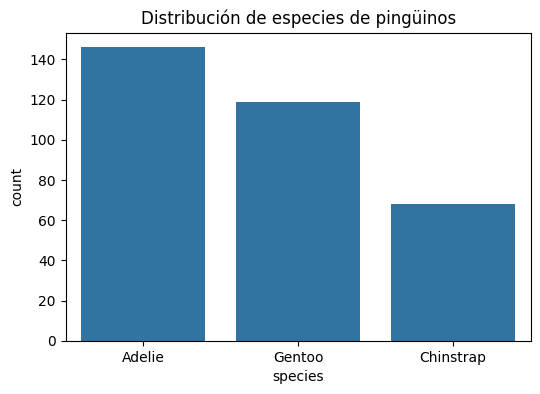

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="species")
plt.title("Distribución de especies de pingüinos")
plt.show()

### Distribución de masa corporal

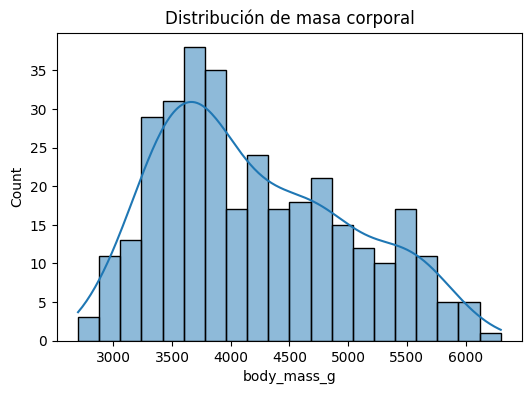

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["body_mass_g"], bins=20, kde=True)
plt.title("Distribución de masa corporal")
plt.show()

###Matriz de correlación

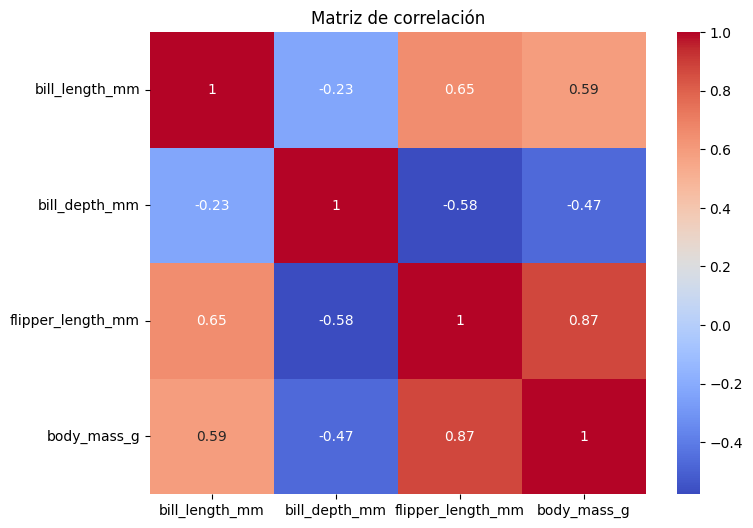

In [17]:
plt.figure(figsize=(8,6))

corr = df[[
"bill_length_mm",
"bill_depth_mm",
"flipper_length_mm",
"body_mass_g"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de correlación")
plt.show()

###Regresión lineal

In [18]:
X = df[["flipper_length_mm", "bill_length_mm"]]
y = df["body_mass_g"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

print("Coeficientes:", modelo.coef_)
print("Intercepto:", modelo.intercept_)

print("R2:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))

Coeficientes: [46.88969374 10.36341277]
Intercepto: -5668.242079525782
R2: 0.7595084473090734
MSE: 143782.6347839463


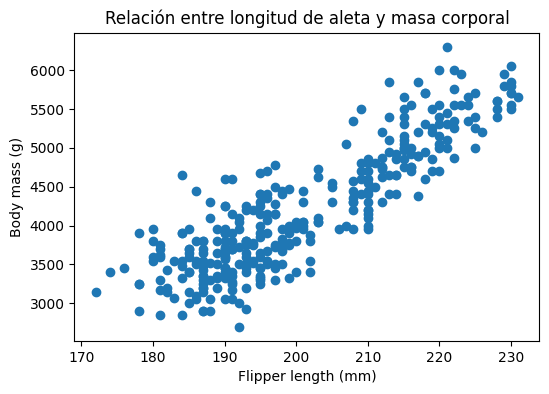

In [19]:
plt.figure(figsize=(6,4))

plt.scatter(df["flipper_length_mm"], df["body_mass_g"])

plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Relación entre longitud de aleta y masa corporal")

plt.show()

###Regresión logística

In [21]:
df["species_code"] = pd.factorize(df["species"])[0]

In [22]:
X = df[[
"bill_length_mm",
"bill_depth_mm",
"flipper_length_mm"
]]

y = df["species_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=200)

log_model.fit(X_train, y_train)

pred = log_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
print("Accuracy:", accuracy_score(y_test, pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred))

Accuracy: 1.0

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        18

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67


Matriz de confusión:
[[31  0  0]
 [ 0 18  0]
 [ 0  0 18]]


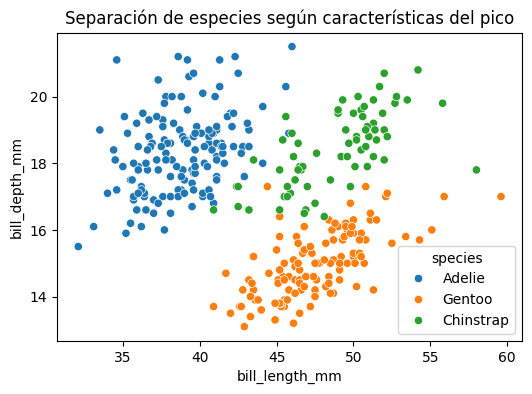

In [24]:
plt.figure(figsize=(6,4))

sns.scatterplot(
data=df,
x="bill_length_mm",
y="bill_depth_mm",
hue="species"
)

plt.title("Separación de especies según características del pico")
plt.show()